In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"D:\DATA SCIENCE COURSE\PROJECTS\financial_risk_project\financial_risk_dataset.csv")
df.head()

,person_age,person_income,person_emp_length,person_home_ownership,loan_intent,loan_amnt,loan_int_rate,credit_score,loan_status
0,59,77767,9,own,personal,32335,13.87,592,1
1,49,48054,17,own,personal,27162,5.44,706,0
2,35,95319,13,rent,home_improvement,24913,5.81,461,1
3,63,122789,17,rent,medical,25687,21.54,802,0
4,28,65397,7,own,business,34220,17.15,747,1


In [7]:
df.shape

(5000, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   person_age             5000 non-null   int64  
 1   person_income          5000 non-null   int64  
 2   person_emp_length      5000 non-null   int64  
 3   person_home_ownership  5000 non-null   object 
 4   loan_intent            5000 non-null   object 
 5   loan_amnt              5000 non-null   int64  
 6   loan_int_rate          5000 non-null   float64
 7   credit_score           5000 non-null   int64  
 8   loan_status            5000 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 351.7+ KB


In [9]:
df.isnull().sum()

person_age               0
person_income            0
person_emp_length        0
person_home_ownership    0
loan_intent              0
loan_amnt                0
loan_int_rate            0
credit_score             0
loan_status              0
dtype: int64

In [10]:
df.head()

,person_age,person_income,person_emp_length,person_home_ownership,loan_intent,loan_amnt,loan_int_rate,credit_score,loan_status
0,59,77767,9,own,personal,32335,13.87,592,1
1,49,48054,17,own,personal,27162,5.44,706,0
2,35,95319,13,rent,home_improvement,24913,5.81,461,1
3,63,122789,17,rent,medical,25687,21.54,802,0
4,28,65397,7,own,business,34220,17.15,747,1


In [11]:
df['loan_status'].value_counts()

loan_status
0    3893
1    1107
Name: count, dtype: int64

In [14]:
df['loan_status'].value_counts(normalize = True) # normalize -> converts counts into percentage

loan_status
0    0.7786
1    0.2214
Name: proportion, dtype: float64

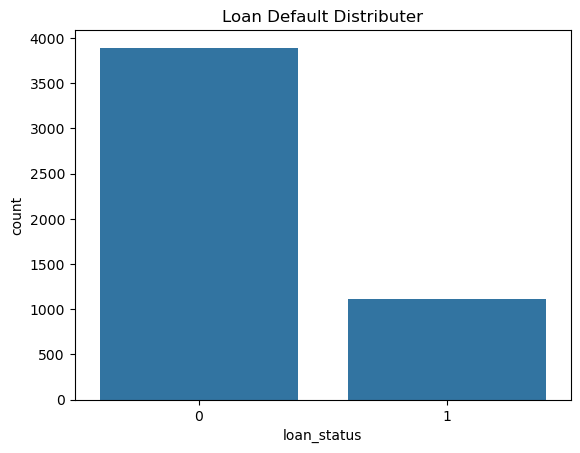

In [15]:
# visualization
sns.countplot(x = 'loan_status', data = df)
plt.title('Loan Default Distributer')
plt.show()


In [23]:
# default loan payment members have more loan amount compared to paid members
df.groupby('loan_status')['loan_amnt'].mean()

loan_status
0    19437.776522
1    23770.371274
Name: loan_amnt, dtype: float64

In [22]:
# credit score can also leads to default
df.groupby('loan_status')['credit_score'].mean()

loan_status
0    590.277935
1    537.037037
Name: credit_score, dtype: float64

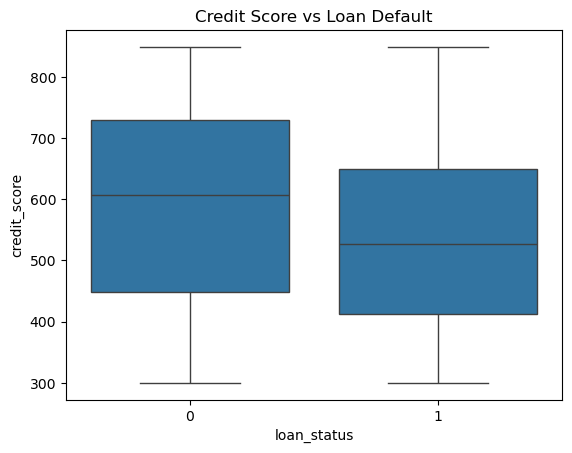

In [18]:
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.title("Credit Score vs Loan Default")
plt.show()

In [20]:
#low income can also leads tho default 
df.groupby('loan_status')['person_income'].mean()

loan_status
0    86090.461855
1    79743.971996
Name: person_income, dtype: float64

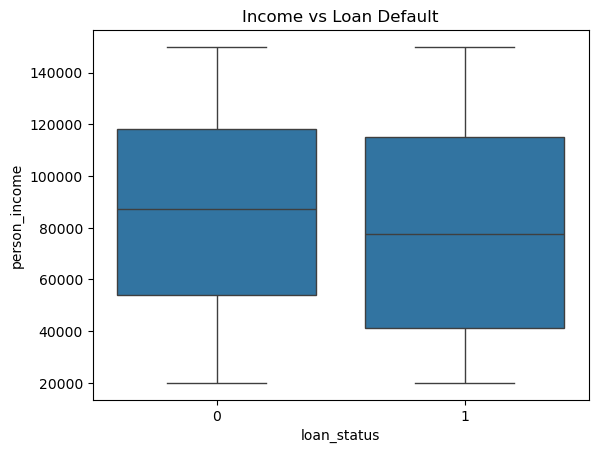

In [24]:
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.title("Income vs Loan Default")
plt.show()

In [30]:
df.groupby('loan_status')['person_income'].mean() # avg person income 

loan_status
0    86090.461855
1    79743.971996
Name: person_income, dtype: float64

In [31]:
# checking which loan purpose will lead to more risk 
df.groupby('loan_intent')['loan_status'].mean()

loan_intent
business              0.244706
debt_consolidation    0.206257
education             0.231144
home_improvement      0.202719
medical               0.224797
personal              0.218159
Name: loan_status, dtype: float64

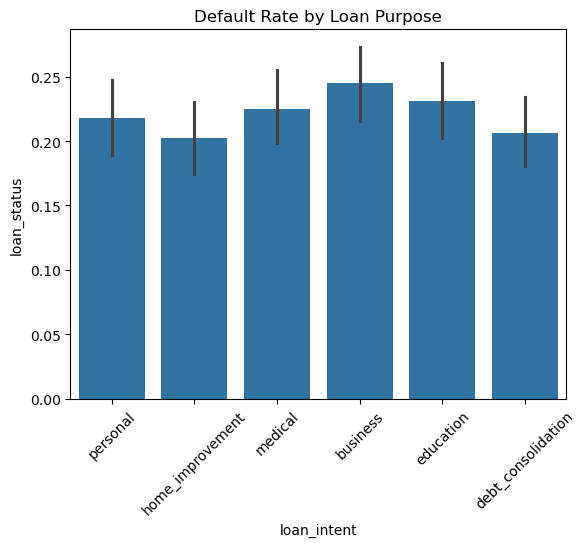

In [34]:
sns.barplot(x='loan_intent', y='loan_status', data=df)
plt.title("Default Rate by Loan Purpose")
plt.xticks(rotation=45)
plt.show()

In [37]:
# checking if risk is high or low 
def risk_category(score):
    if score < 580:
        return "High Risk"
    elif score < 670:
        return "Medium Risk"
    else:
        return "Low Risk"
df['risk_category'] =df['credit_score'].apply(risk_category) # creating a new col
df.head(10)
    
    

,person_age,person_income,person_emp_length,person_home_ownership,loan_intent,loan_amnt,loan_int_rate,credit_score,loan_status,risk_category
0,59,77767,9,own,personal,32335,13.87,592,1,Medium Risk
1,49,48054,17,own,personal,27162,5.44,706,0,Low Risk
2,35,95319,13,rent,home_improvement,24913,5.81,461,1,High Risk
3,63,122789,17,rent,medical,25687,21.54,802,0,Low Risk
4,28,65397,7,own,business,34220,17.15,747,1,Low Risk
5,41,33233,9,own,home_improvement,11995,15.48,754,1,Low Risk
6,59,131205,12,rent,education,3631,23.89,564,0,High Risk
7,39,110020,7,rent,debt_consolidation,35954,8.46,431,0,High Risk
8,43,45068,3,mortgage,medical,6967,10.16,419,0,High Risk
9,31,85727,3,rent,home_improvement,23758,20.13,518,0,High Risk


In [38]:
df['risk_category'].value_counts()

risk_category
High Risk      2495
Low Risk       1661
Medium Risk     844
Name: count, dtype: int64

In [39]:
df.groupby('risk_category')['loan_status'].mean()

risk_category
High Risk      0.288176
Low Risk       0.143889
Medium Risk    0.176540
Name: loan_status, dtype: float64

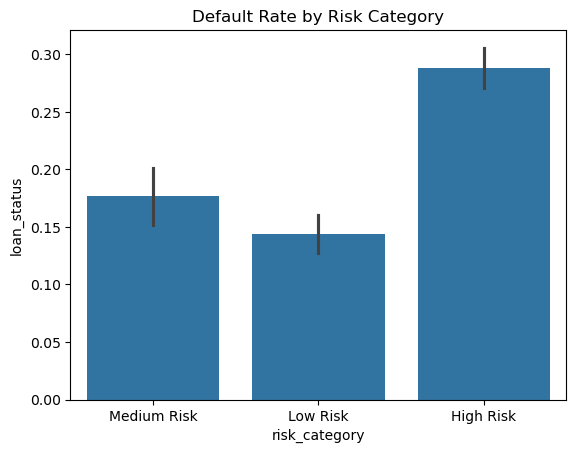

In [40]:
sns.barplot(x='risk_category', y='loan_status', data=df)
plt.title("Default Rate by Risk Category")
plt.show()